# <u>Lab 3 - Noise Cancellation</u>

Goal: in this lab, you will remove the background noise of a sound file.

In this lab you will learn 
- results of adding signals: construction and deconstruction
- find the frequencies of a signal
- spectogram

To turn in to <a href="submit.cs.usna.edu">submit</a>:
- your version of this jupyter notebook with code filled out
  
To turn in to google classroom (<a href="https://classroom.google.com/c/ODM3Nzg4MzY5NDk0?cjc=r6qpxfgb" target="_blank">1133</a> or <a href="https://classroom.google.com/c/ODM3Nzg3MjA3NjAw?cjc=63thu5v4" target="_blank">3333</a>):
- google doc of answered questions - your answers must have justification (This is a LARGE portion of your grade. Please make sure you justify with pictures, i.e. reference the pictures)
- GenAI transcript

In [1]:
#import libraries needed
from numpy.fft import fft, fftfreq
import numpy as np
import matplotlib.pyplot as plt;
from IPython.display import Audio

## Finding frequency, amplitude, and phase offset given a signal:

Create a sinusoid signal with the following parameters:
- sampling rate = 2000  samples per second
- duration      = 1.0 sec
- freq          = 440 Hz # A on piano
- amplitude     = 1

Plot the first 100 samples of the signal with time along the x-axis and magnitude along the y-axis (waveform).

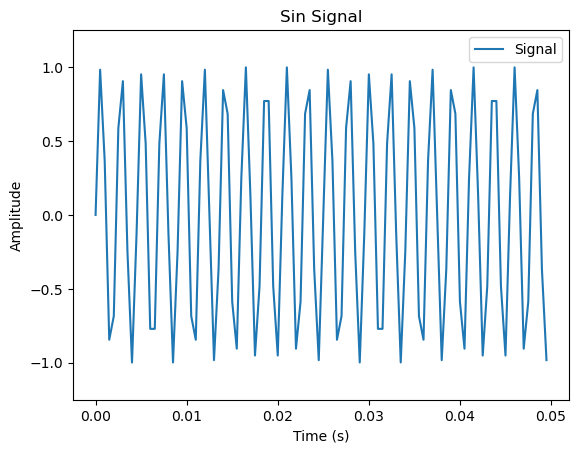

In [7]:
# YOUR CODE HERE: plot the signal
# # feel free to use your code from lab 1
def create_signal(A,w,phi,t):
    return A*np.sin(2*np.pi*w*t + phi)


sampling_rate = 2000
duration = 1.0
freq = 440
amplitude = 1

signal = []

times = np.linspace(0,duration,sampling_rate,endpoint=False)
for time in times:
    signal.append(create_signal(amplitude,freq,0,time))


plt.plot(times[:100], signal[:100], label="Signal")
plt.legend()
plt.ylim(-1.25,1.25)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Sin Signal")
plt.show()

Recall, in Lab 1, you saw that when you added signals together that are opposites, they canceled each other out. One way to construct a signal that is opposite the other is to add $\pi$ to it's phase. 

For example, 

$$\sin(2\pi wt + 0) + \sin(2\pi wt + \pi) = 0$$

- If a wave, when added, increases the magnitude of a signal, it is called a <span style="color:lightblue"><b>constructive wave</b></span>.
- If a wave, when added, decreases the magnitude of a signal, it is called a <span style="color:lightblue"><b>deconstructive wave</b></span>.

Given $s= \sin(10\pi t)$, a deconstructive wave would be $m = \sin(10 \pi t + \pi)$.

Questions:
1. Using matplotlib.pyplot, show $m$ is a deconstructive wave for $s$.
2. Can you give an example of another deconstructive wave? (Hint: recall, Lab 1)

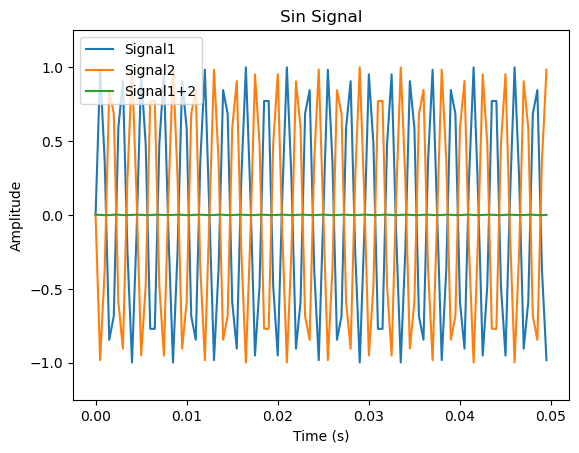

In [8]:
# Answer;
# YOUR CODE HERE
sampling_rate = 2000
duration = 1.0
freq = 440
amplitude = 1

signal1 = []
signal2 = []
signal3 = []

times = np.linspace(0,duration,sampling_rate,endpoint=False)
for time in times:
    signal1.append(create_signal(amplitude,freq,0,time))
    signal2.append(create_signal(amplitude,freq,3.14,time))
    signal3.append(create_signal(amplitude,freq,0,time) + create_signal(amplitude,freq,3.14,time))

plt.plot(times[:100], signal1[:100], label="Signal1")
plt.plot(times[:100], signal2[:100], label="Signal2")
plt.plot(times[:100], signal3[:100], label="Signal1+2")
plt.legend()
plt.ylim(-1.25,1.25)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Sin Signal")
plt.show()

In the above, we showed that if a signal has the exact amplitude and frequency but with a different phase offset, we have deconstruction. 

Questions:

3. What happens if the amplitude of the deconstructive wave is larger? What if it is smaller? (But everything else stays the same)
4. What if the frequency of the deconstructive wave is slightly off, but everything else stays the same?

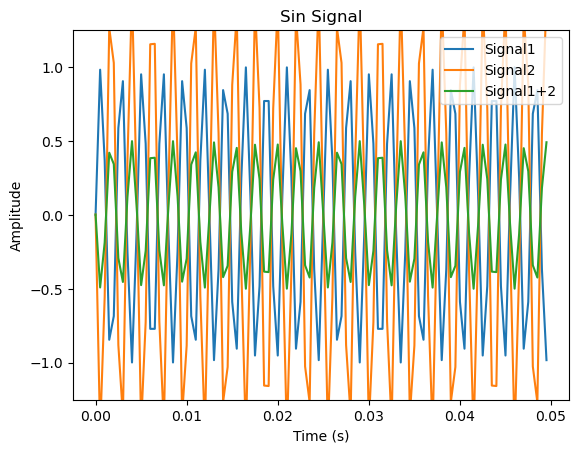

In [ ]:
# Answer:  (show examples)

#QUESTION 3A - deconstructive is larger
# YOUR CODE HERE
sampling_rate = 2000
duration = 1.0
freq = 440
amplitude = 1

signal1 = []
signal2 = []
signal3 = []

times = np.linspace(0,duration,sampling_rate,endpoint=False)
for time in times:
    signal1.append(create_signal(amplitude,freq,0,time))
    signal2.append(create_signal(amplitude+.5,freq,3.14,time))  # increased amplitude of signal2
    signal3.append(create_signal(amplitude,freq,0,time) + create_signal(amplitude+.5,freq,3.14,time))

plt.plot(times[:100], signal1[:100], label="Signal1")
plt.plot(times[:100], signal2[:100], label="Signal2")
plt.plot(times[:100], signal3[:100], label="Signal1+2")
plt.legend()
plt.ylim(-1.25,1.25)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Sin Signal")
plt.show() # the sum of the signals reflects the deconstructive signal, but with its amplitude decreased

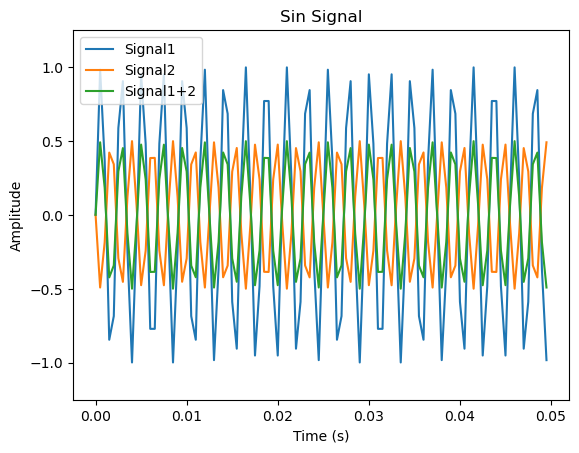

In [ ]:
#QUESTION 3B - deconstructive is smaller
# YOUR CODE HERE
sampling_rate = 2000
duration = 1.0
freq = 440
amplitude = 1

signal1 = []
signal2 = []
signal3 = []

times = np.linspace(0,duration,sampling_rate,endpoint=False)
for time in times:
    signal1.append(create_signal(amplitude,freq,0,time))
    signal2.append(create_signal(amplitude-.5,freq,3.14,time))# decreased amplitude of signal2
    signal3.append(create_signal(amplitude,freq,0,time) + create_signal(amplitude-.5,freq,3.14,time))

plt.plot(times[:100], signal1[:100], label="Signal1")
plt.plot(times[:100], signal2[:100], label="Signal2")
plt.plot(times[:100], signal3[:100], label="Signal1+2")
plt.legend()
plt.ylim(-1.25,1.25)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Sin Signal")
plt.show()  # the sum of the signals reflects the initial signal, but with its amplitude decreased

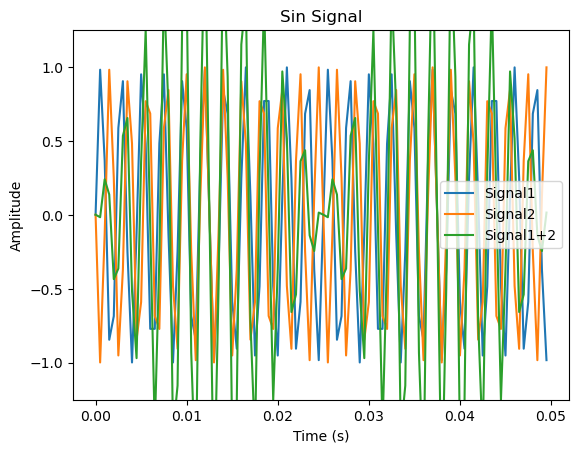

In [ ]:
#QUESTION 4 -deconstructive freq is different
# YOUR CODE HERE
sampling_rate = 2000
duration = 1.0
freq = 440
amplitude = 1

signal1 = []
signal2 = []
signal3 = []

times = np.linspace(0,duration,sampling_rate,endpoint=False)
for time in times:
    signal1.append(create_signal(amplitude,freq,0,time))
    signal2.append(create_signal(amplitude,freq+40,3.14,time))  # deconstructive freq is increased by 40
    signal3.append(create_signal(amplitude,freq,0,time) + create_signal(amplitude,freq+40,3.14,time))

plt.plot(times[:100], signal1[:100], label="Signal1")
plt.plot(times[:100], signal2[:100], label="Signal2")
plt.plot(times[:100], signal3[:100], label="Signal1+2")
plt.legend()
plt.ylim(-1.25,1.25)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Sin Signal")
plt.show()  # because the frequencies are different, it oscillates between constructive and deconstructive depending on the signals being in and out of phase.

## Fourier Transform
So, to eliminate a signal, we have seen that it is important to know a frequency and the phase offset. In order to obtain the frequency or frequencies of a signal, we use a Fourier Transform.

In python, we can use the functions fft and fftfreq from the library scipy. (See notes from class)

Questions:

5. Google (or use a LLM) to find the parameters (i.e. inputs) and outputs of the function fft. List them all.
6. Google (or use a LLM) to find the parameters (i.e. inputs) and outputs of the function fftfreq. List them all.

Let's look at an example of plotting the waveform, spectrum, and spectogram. I have given the beginning of the code. Fill out the rest.

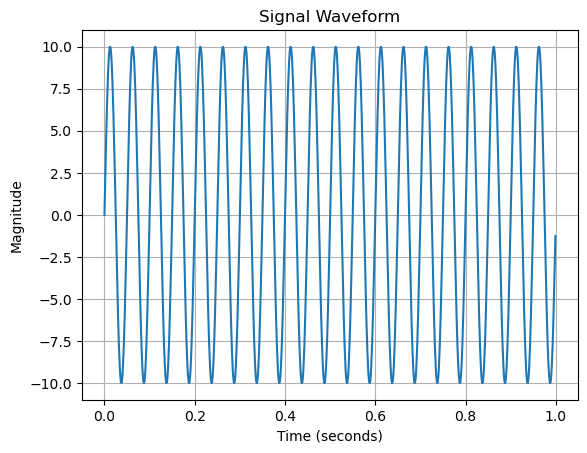

/tmp/ipykernel_67810/3688207315.py:26: UserWarning: Only one segment is calculated since parameter NFFT (=2000) >= signal length (=1000).
  _,_, _, _= plt.specgram(s, NFFT=sampling_rate*2, Fs=sampling_rate, noverlap=10, cmap='viridis')


(0.0, 500.0)

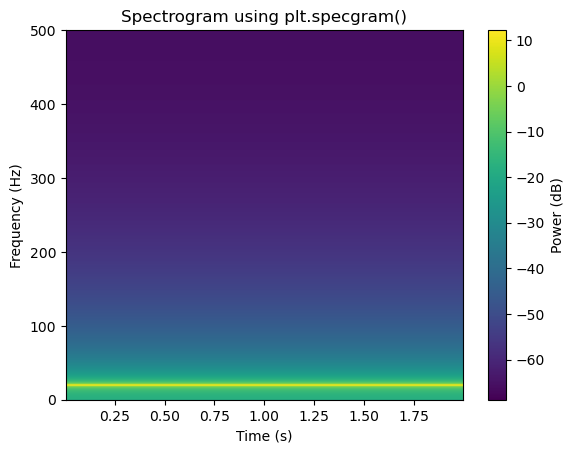

In [ ]:
# Example Code:

# create signal
amplitude = 10
freq = 20
sampling_rate = 1000
duration = 1.0
s = []

times = np.linspace(0,duration,sampling_rate,endpoint=False)
for time in times:
   s.append(create_signal(amplitude, freq, 0, time)) 
   
# YOUR CODE HERE
# plot waveform of signal
plt.figure()
plt.plot(times, s)


plt.xlabel("Time (seconds)")
plt.ylabel("Magnitude")
plt.title("Signal Waveform")
plt.grid(True)
plt.show()

# plot the spectogram of the signal
_,_, _, _= plt.specgram(s, NFFT=sampling_rate*2, Fs=sampling_rate, noverlap=10, cmap='viridis')
plt.colorbar(label='Power (dB)')
plt.title('Spectrogram using plt.specgram()')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.ylim(0, sampling_rate/2) # Show only up to the Nyquist frequency

Recall in class we discussed how there are both negative and positive frequencies when using the Fourier Transform. Note that your plot above includes both the positive and negative. In the below, we will only look at the positive frequencies and find the frequency with the largest magnitude.

(If needed, see the notes of FFT on the class website)

In [ ]:

#YOUR CODE HERE
# Create a list of just the positive frequencies from the entire list of frequencies given from fftfreq. (That is, slice the initial list)
n = len(s)
d = 1.0 / sampling_rate

# 1. Generate all frequencies
freqs = fftfreq(n, d)

# 2. Slice to get only the positive half
# For both even and odd n, this captures the non-negative frequencies
pos_freqs = freqs[:n//2]


# using your list of positive frequencies, create a list of the weights of the positive frequencies. Recall, the weights are returned
# by the fft
signal_fft = fft(s)
pos_fft_values = signal_fft[:n//2]


# print out the largest magnitude (note: -5 has larger magnitude than 3) from your list:
max_mag = np.max(np.abs(s))


# print out the frequency with largest absolute magnitude  (np.argmax is your best friend)
np.argmax()




In [ ]:
# create a new plot with only positive frequencies: x-positive frequencies, y- magnitude



# zoom in to the lower frequencies 0-100, including both ends (one can use np.where)




# Did you get the correct frequency according to your plots?

Let's now look at the spectogram of the signal from above. 

<b>Create at least three spectograms, each having a different number of bins for the Fourier Transform</b>

Questions:
 
7. What happens to the spectogram if you decrease the number of bins used for the fft?
8. What happens to the spectogram if you increase the number of bins used for the fft?

In [ ]:
# YOUR CODE HERE: use this space to answer the above questions.
# plotting the spectogram plt.figure(); 





## Noise Cancellation

In order to cancel out a signal, we need to know a few things about it:
- frequency
- phase offset
- amplitude

We now have an idea on how to grab its frequency. So, lets consider the next two items.



Recall, the fft returns a complex array where each entry is a weight for a frequency. That is,

$$\begin{align}fft(s) &= [weight(freq 0), weight(freq 1), \ldots, weight(freq N)]\\
                      &= [X_{f0}, X_{f1}, \ldots, X_{fN}] \end{align}$$
                      
To find the amplitude of a signal for a given frequency using the fourier transform, we have the following:

$$amplitude = \frac{2*abs(X_f)}{N}$$


where $N$ is the length of the fourier transform (i.e. number of points for the transform).

To find the phase of a signal for a given frequency, we use the formula:

$$phase(freq) = \arctan(X_f).$$

In the above, we are taking the value of the fft of the frequency and computing its arctangent. 

<i>Python Hint:</i> To compute the arctangent in python with complex values, we use np.arctan2(real part, imag part).

Questions:

9. given the following signal in the code block below, find the frequency, phase and amplitude

In [ ]:
# given the following signal, find the frequency, phase and amplitude:
s = np.load("/SI486H/lab3/signal.npy")

# givens: sampling_rate = 1000, duration = 1.0 sec

#YOUR CODE HERE
# obtain the weights and the frequncies of the signal (the entirety - so number of samples/bins = len of signal)




# plot the spectrum (horizontal - freq, vertical - magnitude) with only positive frequencies






# find the positive frequency with the largest magnitude:





# find the phase offset of the positive frequency with largest magnitude:




# find the amplitude of the frequency using the weight given by the fourier transform






Question:

10. Using the frequency, amplitude, and phase found, cancel out the signal by adding its opposite. 

Note: you must use the frequency and phase found. No points will be given if you just subtract the signal from itself.

In [ ]:
# YOUR CODE HERE: use this space to write code to help you answer the above question
# create the signal to be used to cancel out the original signal from above

# plot all 3 signals on the same plot: original, the deconstructive signal, original + deconstructive signal
# make sure you label using the legend feature

## Noise Cancellation - Multiple Frequencies

One pure tone is simple enough to cancel, but what if we are talking about a voice over noise, such as a lawn mower. How does this work? 
Most companies use a concept called MISO (Multiple Inputs Single Output). They use two microphones - one to focus on extraneous noise and one to collect sounds in general.
So, with two audio signals, one with noise and one with the voice over noise, we can subtract. HOWEVER, sadly, it is not that simple. We have to worry about the phase for every single frequency.

For the sake of the length of the lab, we are not going to try our hands at this. But, I highly recommend reading up on it!